In [ ]:
#Monday: Dillan Andrews, Alex Velasquez
#Wednesday: Dillan Andrews, Alex Velasquez
#https://www.kaggle.com/datasets/vishardmehta/smartphone-battery-health-prediction-dataset

In [ ]:
#Import Libraries
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import time

In [ ]:
#Load smart phone dataset
df = pd.read_csv('smartphone_battery_features.csv')

X = df[['device_age_months','battery_capacity_mah','avg_screen_on_hours_per_day','avg_charging_cycles_per_week','avg_battery_temp_celsius','fast_charging_usage_percent','overnight_charging_freq_per_week','gaming_hours_per_week','video_streaming_hours_per_week','charging_habit_score','usage_intensity_score','thermal_stress_index']]
y = df['recommended_action']
classes = df['recommended_action']
#Use standard scaler to moderate the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f"\nDataset: Smartphone Batteries")
print(f"Number of samples: {len(y)}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")

#create dummy variables for y
le = LabelEncoder()
y = le.fit_transform(y)


Dataset: Smartphone Batteries
Number of samples: 5000
Number of features: 12
Number of classes: 3
Classes: ['Change Phone' 'Keep Using' 'Replace Battery']


In [ ]:
#create a train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#use Standard SVM (OvO)
start_time = time.time()
model_standard = SVC(kernel='rbf', gamma='scale', C=1.0)
model_standard.fit(X_train, y_train)
train_time_standard = time.time() - start_time

y_pred_standard = model_standard.predict(X_test)
accuracy_standard = accuracy_score(y_test, y_pred_standard)

print(f"\nResults:")
print(f"  Training time: {train_time_standard:.4f} seconds")
print(f"  Accuracy: {accuracy_standard * 100:.2f}%")


Results:
  Training time: 0.2269 seconds
  Accuracy: 90.13%


In [ ]:
#OvA

start_time = time.time()
model_ovr = OneVsRestClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
model_ovr.fit(X_train, y_train)
train_time_ovr = time.time() - start_time

y_pred_ovr = model_ovr.predict(X_test)
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)

print(f"\nResults:")
print(f"  Training time: {train_time_ovr:.4f} seconds")
print(f"  Accuracy: {accuracy_ovr * 100:.2f}%")
print(f"  Number of classifiers trained: {len(model_ovr.estimators_)}")


Results:
  Training time: 0.6968 seconds
  Accuracy: 89.80%
  Number of classifiers trained: 3


In [ ]:
#Another OvO Method

start_time = time.time()
model_ovo = OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
model_ovo.fit(X_train, y_train)
train_time_ovo = time.time() - start_time

y_pred_ovo = model_ovo.predict(X_test)
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)

print(f"\nResults:")
print(f"  Training time: {train_time_ovo:.4f} seconds")
print(f"  Accuracy: {accuracy_ovo * 100:.2f}%")
print(f"  Number of classifiers trained: {len(model_ovo.estimators_)}")


Results:
  Training time: 1.1284 seconds
  Accuracy: 90.13%
  Number of classifiers trained: 3


In [ ]:
print("\n" + "=" * 70)
print("FINAL COMPARISON SUMMARY")
print("=" * 70)

print(f"\n{'Strategy':<20} {'Accuracy':<12} {'Training Time':<15} {'# Classifiers'}")
print("-" * 70)
print(f"{'Standard SVM':<20} {accuracy_standard*100:>6.2f}%     {train_time_standard:>8.4f}s      N/A (built-in)")
print(f"{'One-vs-Rest (OvA)':<20} {accuracy_ovr*100:>6.2f}%     {train_time_ovr:>8.4f}s      {len(model_ovr.estimators_)}")
print(f"{'One-vs-One (OvO)':<20} {accuracy_ovo*100:>6.2f}%     {train_time_ovo:>8.4f}s      {len(model_ovo.estimators_)}")

accuracies = {
    'Standard SVM': accuracy_standard,
    'One-vs-Rest (OvA)': accuracy_ovr,
    'One-vs-One (OvO)': accuracy_ovo
}
best_strategy = max(accuracies, key=accuracies.get)
print(f"\nBest accuracy: {best_strategy}")

print("\n" + "=" * 70)
print("DETAILED CLASSIFICATION REPORT (One-vs-One Strategy)")
print("=" * 70)
print(classification_report(y_test, y_pred_ovo, target_names=np.unique(classes)))



FINAL COMPARISON SUMMARY

Strategy             Accuracy     Training Time   # Classifiers
----------------------------------------------------------------------
Standard SVM          90.13%       0.2269s      N/A (built-in)
One-vs-Rest (OvA)     89.80%       0.6968s      3
One-vs-One (OvO)      90.13%       1.1284s      3

Best accuracy: Standard SVM

DETAILED CLASSIFICATION REPORT (One-vs-One Strategy)
                 precision    recall  f1-score   support

   Change Phone       0.91      0.89      0.90       366
     Keep Using       0.89      0.93      0.91       423
Replace Battery       0.90      0.89      0.89       711

       accuracy                           0.90      1500
      macro avg       0.90      0.90      0.90      1500
   weighted avg       0.90      0.90      0.90      1500




Generating visualization...


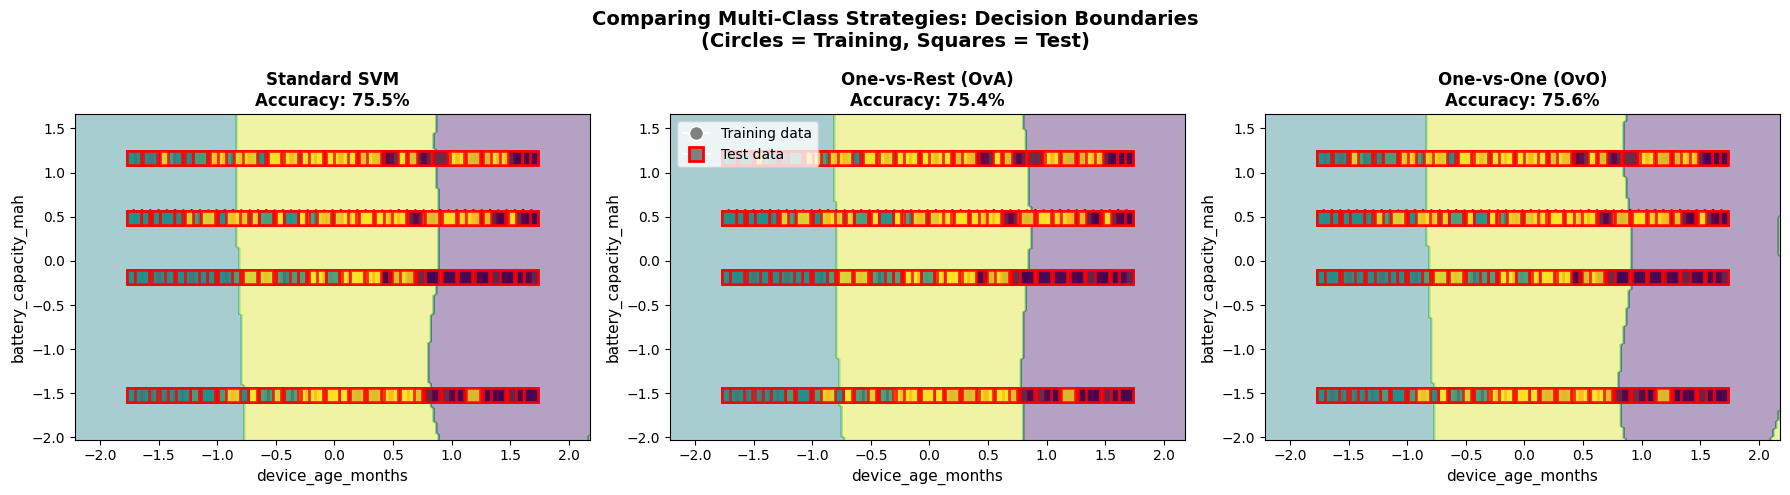

In [ ]:
print("\nGenerating visualization...")

X_2d = X[:,:2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42
)

models_2d = {
    'Standard SVM': SVC(kernel='rbf', gamma='scale', C=1.0),
    'One-vs-Rest (OvA)': OneVsRestClassifier(SVC(kernel='rbf', gamma='scale', C=1.0)),
    'One-vs-One (OvO)': OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
for idx, (name, model) in enumerate(models_2d.items()):
    model.fit(X_train_2d, y_train_2d)

    y_pred_2d = model.predict(X_test_2d)
    acc_2d = accuracy_score(y_test_2d, y_pred_2d)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    #xx = np.array(xx, dtype = float)
    #yy = np.array(yy, dtype = float)
    #Z = np.array(Z, dtype = float)
    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap='viridis')

    scatter = axes[idx].scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                               c=y_train_2d, edgecolors='k',
                               cmap='viridis', s=100, alpha=0.8)

    axes[idx].scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                     c=y_test_2d, edgecolors='red', linewidths=2,
                     cmap='viridis', s=100, alpha=0.8, marker='s')

    axes[idx].set_xlabel('device_age_months', fontsize=11)
    axes[idx].set_ylabel('battery_capacity_mah', fontsize=11)
    axes[idx].set_title(f'{name}\nAccuracy: {acc_2d*100:.1f}%',
                       fontsize=12, fontweight='bold')

    from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=10, label='Training data'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
           markeredgecolor='red', markeredgewidth=2, markersize=10, label='Test data')
]
axes[1].legend(handles=legend_elements, loc='upper left')

plt.suptitle('Comparing Multi-Class Strategies: Decision Boundaries\n(Circles = Training, Squares = Test)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "=" * 70)
print("NUMBER OF CLASSIFIERS FOR DIFFERENT CLASS COUNTS")
print("=" * 70)
print(f"\n{'# Classes':<12} {'One-vs-Rest (OvA)':<20} {'One-vs-One (OvO)'}")
print("-" * 70)

for n_classes in [3, 5, 10, 20, 50, 100]:
    n_ovr = n_classes
    n_ovo = n_classes * (n_classes - 1) // 2
    print(f"{n_classes:<12} {n_ovr:<20} {n_ovo}")


NUMBER OF CLASSIFIERS FOR DIFFERENT CLASS COUNTS

# Classes    One-vs-Rest (OvA)    One-vs-One (OvO)
----------------------------------------------------------------------
3            3                    3
5            5                    10
10           10                   45
20           20                   190
50           50                   1225
100          100                  4950


The dataset used for this program involves various factors that can affect the battery life of a smartphone. Using these factors, we can predict whether the phone should keep being used, have its battery replaced, or should be replaced all together. Using these factors in an OvA and OvO comparison program, we can predict how a smartphone should be treated with an accuracy of around 90%. The Standard SVM model had the highest accuracy and lowest processing time, so it should be used in the future when predicting when to replace a smart phone.